In [1]:
import zipfile
import os

# Unzip uploaded file
with zipfile.ZipFile("C:\\Users\\mazen\\Downloads\\Teeth DataSet.zip", 'r') as zip_ref:
    zip_ref.extractall("Teeth_Dataset")

# Change directory to it if needed
os.listdir("Teeth_Dataset")

['Teeth_Dataset', 'Testing', 'Training', 'Validation']

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
train='C:\\Users\\mazen\\Downloads\\Teeth DataSet.zip\\Training'
batch_size=32
img_height=224
img_width=224


In [4]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

# ✅ 4) Define transforms like Keras ImageDataGenerator (Normalization same as ResNet50)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ✅ Path to your image folder
data_root = "Teeth_Dataset/Training"  # <-- change this if path is different

# ✅ 4) Create dataset
dataset = ImageFolder(root=data_root, transform=train_transforms)
print(f"📸 Total Images Found: {len(dataset)} | Classes: {dataset.classes}")

# ✅ 5) Split dataset into Train & Validation
val_fraction = 0.2  # 20% for validation like Keras
val_size = int(len(dataset) * val_fraction)
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

print(f"🔀 Train Samples: {len(train_dataset)} | Val Samples: {len(val_dataset)}")

# ✅ 6) Create DataLoaders
batch_size = 32  # same as Keras default
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("✅ DataLoaders Ready!")


📸 Total Images Found: 3087 | Classes: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
🔀 Train Samples: 2470 | Val Samples: 617
✅ DataLoaders Ready!


In [5]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

# Path to dataset folder (change to your actual path)
data_root = "Teeth_Dataset/Training"

# ✅ SAME transforms used in training
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ✅ Create dataset
dataset = ImageFolder(root=data_root, transform=train_transforms)

# ✅ Split dataset
val_fraction = 0.2
val_size = int(len(dataset) * val_fraction)
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

# ✅ Create DataLoaders
batch_size = 32  # or any number you want

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("✅ DataLoaders ready! Total train batches:", len(train_loader), " | Total val batches:", len(val_loader))


✅ DataLoaders ready! Total train batches: 78  | Total val batches: 20


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ✅ Load pretrained ResNet101
model_resnet = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)

# ✅ Freeze feature extractor
for param in model_resnet.parameters():
    param.requires_grad = False

# ✅ Replace classifier head
model_resnet.fc = nn.Sequential(
    nn.Linear(2048, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 7)  # 7 classes ✅
)

model_resnet = model_resnet.to(device)

# ✅ Loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_resnet.fc.parameters(), lr=1e-4)


Using device: cuda


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to C:\Users\Mazen/.cache\torch\hub\checkpoints\resnet101-63fe2227.pth
100%|██████████| 171M/171M [03:00<00:00, 989kB/s]  


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import torchvision.models as models

# -------------------------------
# ✅ Setup Device (GPU or CPU)
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------
# ✅ Load EfficientNet-B3
# -------------------------------
model_eff = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

# Freeze base layers (optional)
for param in model_eff.features.parameters():
    param.requires_grad = False

# Replace classifier
num_features = model_eff.classifier[1].in_features
model_eff.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 7),  # 7 classes for your teeth dataset
)

model_eff = model_eff.to(device)
print("EfficientNet-B3 model loaded and moved to GPU ✅")

# -------------------------------
# ✅ Loss, Optimizer, and Scaler
# -------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_eff.parameters(), lr=1e-4)
scaler = torch.cuda.amp.GradScaler()  # for mixed precision

# -------------------------------
# ✅ Early Stopping Class
# -------------------------------
class EarlyStopping:
    def __init__(self, patience=8, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"⏳ EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# -------------------------------
# ✅ Initialize Early Stopping
# -------------------------------
early_stopper = EarlyStopping(patience=8, min_delta=0.001)

# -------------------------------
# ✅ Training Loop with Mixed Precision
# -------------------------------
num_epochs = 50

for epoch in range(num_epochs):
    print(f"\n🔹 Epoch {epoch+1}/{num_epochs}")
    model_eff.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        # Mixed precision forward & backward
        with torch.cuda.amp.autocast():
            outputs = model_eff(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    print(f"✅ Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f}")

    # -------------------------------
    # 🔹 Validation
    # -------------------------------
    model_eff.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)
            with torch.cuda.amp.autocast():
                outputs = model_eff(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)
    print(f"🎯 Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # -------------------------------
    # 🔹 Apply Early Stopping
    # -------------------------------
    early_stopper(avg_val_loss)
    if early_stopper.early_stop:
        print("⛔ Training stopped early due to no improvement.")
        break


Using device: cuda


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to C:\Users\Mazen/.cache\torch\hub\checkpoints\efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:49<00:00, 991kB/s] 
C:\Users\Mazen\AppData\Local\Temp\ipykernel_20908\3098128729.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # for mixed precision


EfficientNet-B3 model loaded and moved to GPU ✅

🔹 Epoch 1/50


Training:   0%|          | 0/78 [00:00<?, ?it/s]C:\Users\Mazen\AppData\Local\Temp\ipykernel_20908\3098128729.py:88: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training: 100%|██████████| 78/78 [00:26<00:00,  2.94it/s]


✅ Train Loss: 1.9106 | Train Acc: 0.2166


...

🎯 Val Loss: 0.3537 | Val Acc: 0.8801
⏳ EarlyStopping counter: 4/8

🔹 Epoch 50/50


Training: 100%|██████████| 78/78 [00:27<00:00,  2.81it/s]


✅ Train Loss: 0.4258 | Train Acc: 0.8538


Validating: 100%|██████████| 20/20 [00:23<00:00,  1.20s/it]

🎯 Val Loss: 0.3365 | Val Acc: 0.8914


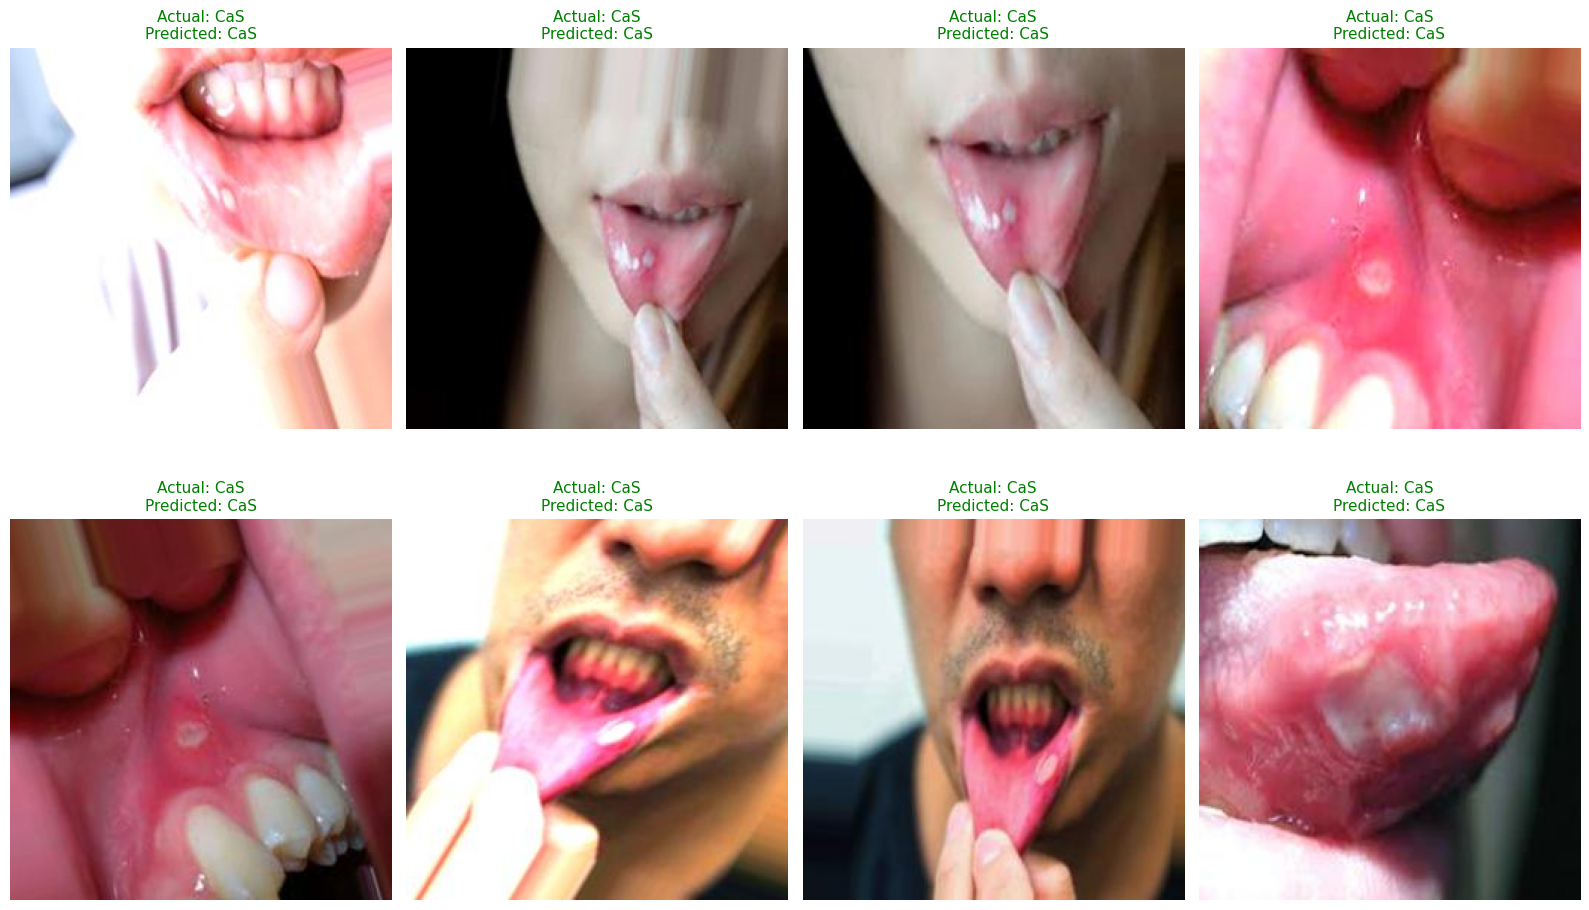

In [16]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# ✅ Paths
test_dir = 'C:\\Users\\Mazen\\Downloads\\AMIT\\Teeth_Dataset\\Testing'
class_labels = dataset.classes
class_labels = list(class_labels)  # Ensure order is consistent with dataset

# ✅ Transformation (same as used in training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ✅ Collect test images and labels
test_images = []
for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                test_images.append((os.path.join(class_path, img_name), class_name))

# ✅ Select 8 test samples
test_images = test_images[10:18]

# ✅ Plot setup
plt.figure(figsize=(16, 10))

model_eff.eval()  # Set model to evaluation mode
with torch.no_grad():
    for i, (img_path, actual_label) in enumerate(test_images):
        # Load and preprocess image
        img = Image.open(img_path).convert("RGB")
        img_tensor = transform(img).unsqueeze(0).to(device)

        # Forward pass
        outputs = model_eff(img_tensor)
        _, pred_class = torch.max(outputs, 1)
        pred_label = class_labels[pred_class.item()]

        # ✅ Display image with actual & predicted labels
        plt.subplot(2, 4, i + 1)
        plt.imshow(Image.open(img_path))
        plt.axis('off')

        color = 'green' if pred_label == actual_label else 'red'
        plt.title(f"Actual: {actual_label}\nPredicted: {pred_label}",
                  fontsize=11, color=color, loc='center')

plt.tight_layout()
plt.show()
